# Engineering Neural Networks Portfolio Project

## Setup

In [39]:
!pip install -r requirements.txt

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

  Using cached numpy-2.2.6-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached scipy-1.15.3-cp312-cp312-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached numexpr-2.10.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (1.2 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached torch-2.4.1-cp312-none-macosx_11_0_arm64.whl.metadata (26 kB)
  Using cached torchvision-0.19.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.0 kB)
ERROR: Ignored the following 

## Project Framework

### 1. Business Understanding: Use AI to automate classification of customer banking queries into predefined intent categories to improve routing, response time, and customer experience.


- Improve first-response accuracy
- Reduce manual triage time for customer support

### 2. Data Understanding: The Banking77 dataset contains labeled customer queries across 77 banking intent classes.

- Inspect class distribution and identify imbalances
- Analyze text lengths across intent classes

### 3. Data Preparation: Clean and preprocess text for modeling.

- Normalize, pad, and/or truncate text
- Tokenization using transformer-compatible tokenizers

### 4. Modeling: Finetuned transformer-based model for contextual understanding and performance.

- Baseline: Multi-Layer Perceptron (MLP)
- Advanced model: Finetuned RoBERTa using LoRA

### 5. Evaluation: Define classification performance metrics.

- Primary metric: Macro F1 Score
- Secondary metrics: Overall accuracy, precision, recall
- Comparison: Baseline vs advanced model performance

### 6. Deployment: Save and load the finetuned LoRA-RoBERTa model.

- AI ethics: Ensure data security and privacy of customer queries by redacting sensitive personally identifiable information (PII)
- Inference pipeline: Customer query -> Redact PII -> Predict banking intent
- Monitor: Track live performance, potential data drift, and collect data for retraining

## Exploratory Data Analysis

In [28]:
# Import the datasets
train = pd.read_csv('/Users/Alex/Documents/Coding/3. AI Engineer Career Path/engineer-neural-networks-portfolio-project/datasets/banking77_train.csv')
test = pd.read_csv('/Users/Alex/Documents/Coding/3. AI Engineer Career Path/engineer-neural-networks-portfolio-project/datasets/banking77_test.csv')

# Print key info
print("Train DataFrame:")
print("\nInfo: \n", train.info())
print("\nNull Values: \n", train.isna().sum())
print("\nInitial Values: \n", train.head())
print("\nShape: \n", train.shape)

print("\nTest DataFrame:")
print("\nInfo: \n", test.info())
print("\nNull Values: \n", test.isna().sum())
print("\nInitial Values: \n", test.head())
print("\nShape: \n", test.shape)

Train DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      10003 non-null  str  
 1   category  10003 non-null  str  
dtypes: str(2)
memory usage: 943.8 KB

Info: 
 None

Null Values: 
 text        0
category    0
dtype: int64

Initial Values: 
                                                 text      category
0                     I am still waiting on my card?  card_arrival
1  What can I do if my card still hasn't arrived ...  card_arrival
2  I have been waiting over a week. Is the card s...  card_arrival
3  Can I track my card while it is in the process...  card_arrival
4  How do I know if I will get my card, or if it ...  card_arrival

Shape: 
 (10003, 2)

Test DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 3080 entries, 0 to 3079
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 

<>:12: SyntaxWarning: invalid escape sequence '\T'
<>:12: SyntaxWarning: invalid escape sequence '\T'
/var/folders/57/cryl7wqx1fn9pftrpn26lzwc0000gp/T/ipykernel_27225/26407017.py:12: SyntaxWarning: invalid escape sequence '\T'
  print("\Test Unique Labels: \n", test.value_counts("category"))


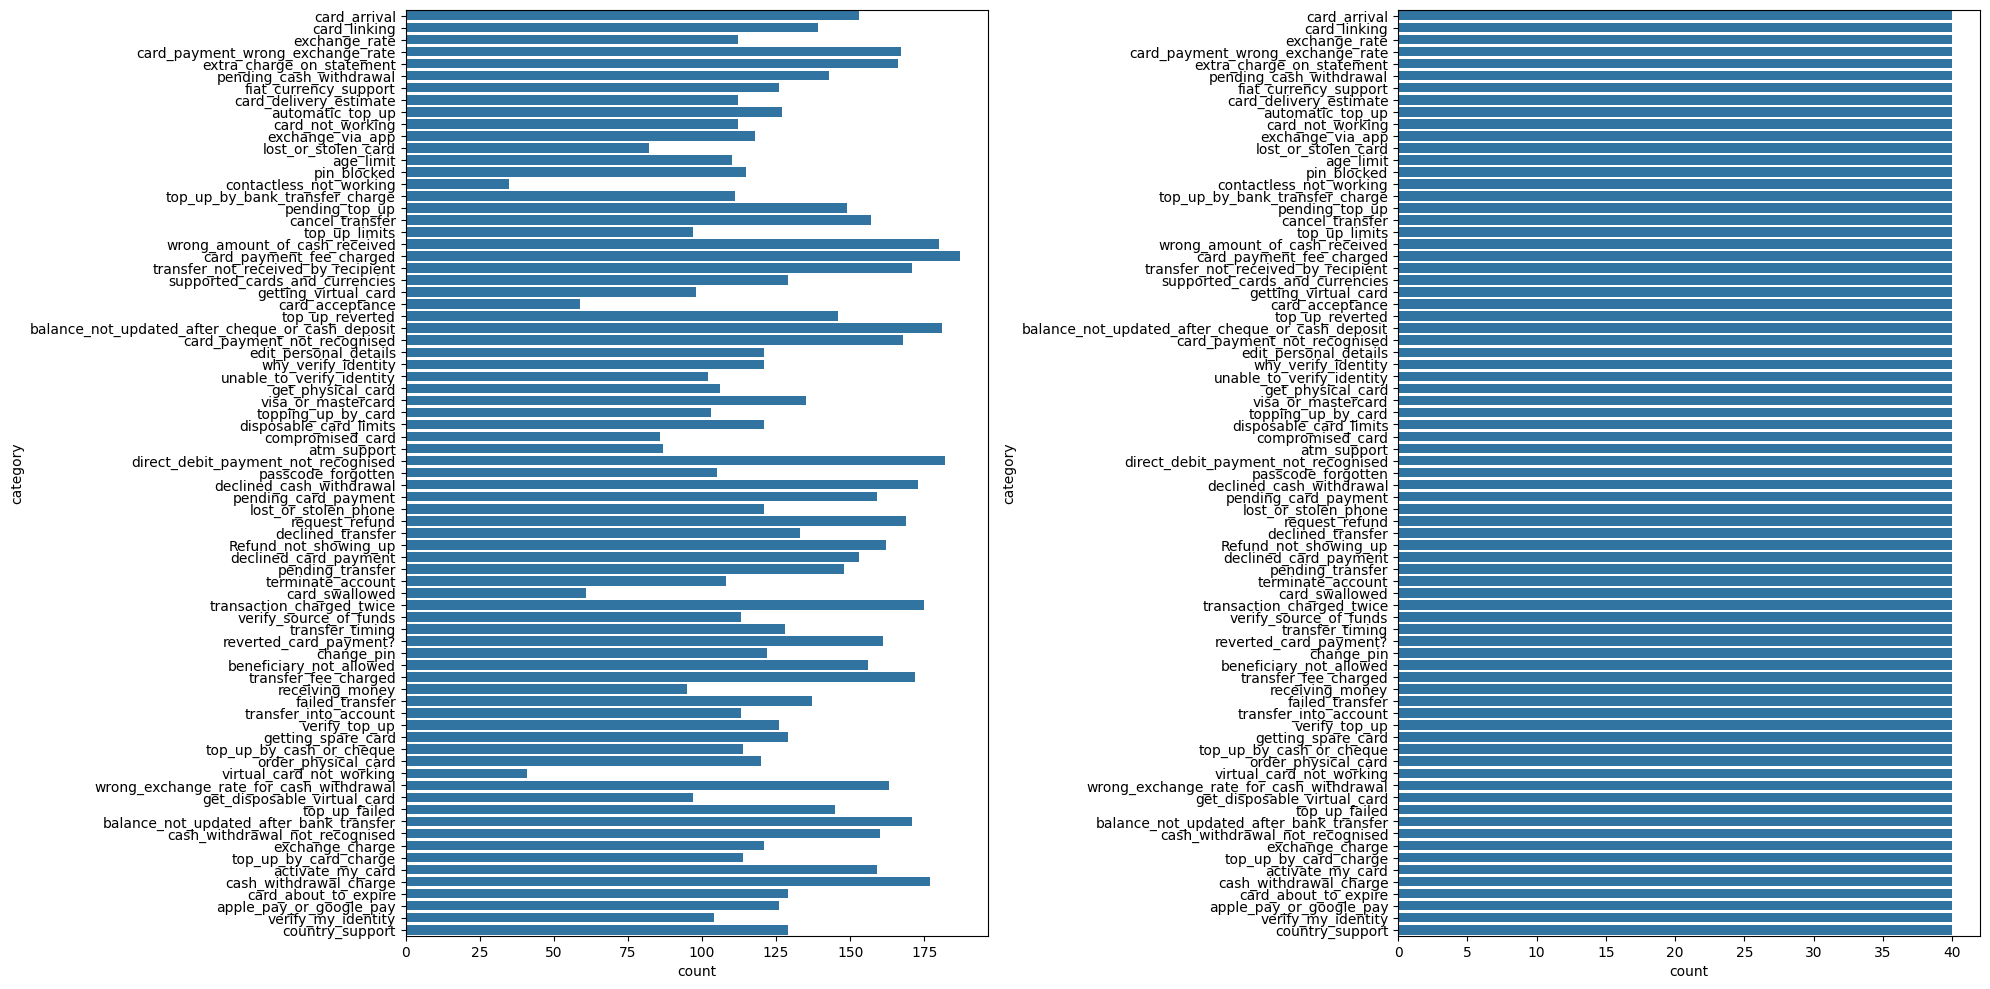


Train Unique Labels: 
 category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64
\Test Unique Labels: 
 category
card_arrival                        40
card_linking                        40
exchange_rate                       40
card_payment_wrong_exchange_rate    40
extra_charge_on_statement           40
                                    ..
cash_withdrawal_charge              40
card_abo

In [38]:
# Calculate number of unique labels
train_label_count = train.value_counts("category")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
sns.countplot(data=train, y="category", ax=ax1)
sns.countplot(data=test, y="category", ax=ax2)
plt.tight_layout()
plt.show()

print("\nTrain Unique Labels: \n", train_label_count)
print("\Test Unique Labels: \n", test.value_counts("category"))

In [49]:
# Count top words per category
def count_top_words(df):
    # Initialise top_words dict
    top_words = {}

    # Create series grouped by Category
    grouped = df.groupby('category')['text'].apply(' '.join)

    # Loop over each text combination to calculate top 5 word occurrences
    for category, text in grouped.items():
        top_words[category] = Counter(text.split()).most_common(5)

    return top_words

count_top_words(train)
count_top_words(test)

{'Refund_not_showing_up': [('my', 41),
  ('I', 39),
  ('a', 37),
  ('refund', 30),
  ('and', 14)],
 'activate_my_card': [('my', 32),
  ('I', 32),
  ('activate', 21),
  ('to', 20),
  ('card', 18)],
 'age_limit': [('to', 37),
  ('an', 26),
  ('open', 18),
  ('my', 17),
  ('account?', 17)],
 'apple_pay_or_google_pay': [('top', 27),
  ('I', 26),
  ('my', 23),
  ('Apple', 20),
  ('up', 19)],
 'atm_support': [('I', 20),
  ('this', 17),
  ('ATMs', 15),
  ('card?', 13),
  ('can', 13)],
 'automatic_top_up': [('I', 25),
  ('auto', 15),
  ('there', 14),
  ('top-up', 13),
  ('money', 11)],
 'balance_not_updated_after_bank_transfer': [('I', 30),
  ('my', 29),
  ('transfer', 25),
  ('a', 23),
  ('it', 17)],
 'balance_not_updated_after_cheque_or_cash_deposit': [('my', 35),
  ('I', 34),
  ('to', 21),
  ('a', 21),
  ('cash', 21)],
 'beneficiary_not_allowed': [('to', 37),
  ('I', 31),
  ('a', 27),
  ('transfer', 27),
  ('Why', 12)],
 'cancel_transfer': [('I', 41),
  ('a', 31),
  ('to', 28),
  ('cancel',

In [ ]:
# 